# Healthcare Appointment Data - Exploratory Data Analysis (EDA)
## Appointment Slot Recommendation System

### Purpose
This notebook performs exploratory data analysis on healthcare appointment records to understand:
- Patient demographics and appointment patterns
- Provider availability and scheduling trends
- Appointment status distribution (Confirmed, Cancelled, Rescheduled)
- Insurance coverage patterns
- Temporal trends in appointment scheduling

### Dataset Overview
The dataset contains **1000 appointment records** with **81 columns** including:
- Patient information (demographics, contact, insurance)
- Provider details
- Appointment scheduling data
- Visit reasons and types
- Payment and billing information

### Why This Data Matters
Understanding appointment patterns is crucial for:
- Optimizing provider schedules
- Reducing no-shows and cancellations
- Improving patient access to care
- Building ML models for slot recommendations

## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [24]:
df = pd.read_csv('../dataset/raw/full_appointments.csv', skipinitialspace=True)

print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded successfully!
Shape: 1000 rows × 81 columns


,_id,patientId,patientName,dob,sex,providerId,providerName,visitReasonId,visitReasonName,visitReasonmsg,...,secondaryInsurance_medicalGroup,secondaryInsurance_pcp,secondaryInsurance_coverageStartDate,secondaryInsurance_terminationDate,secondaryInsurance_insuranceStatus,secondaryInsurance_guarantor,secondaryInsurance_guarantorName,secondaryInsurance_guarantorAddress,secondaryInsurance_guarantorDOB,secondaryInsurance_guarantorSubscriberId
0,6901bc2fa0d320ebecfb91c8,4c540d59a964827cfa54df0a,"""JONES, JANICE""",07/10/1934,F,694091fb838ec587cd2138e3,"Evelyn Bright, NP",6983fe903f0e0c5fa19168fa,Home Visit,Muscle / Joint Pain,...,,,,,,,,,,NaN
1,214538818247ef21abe39e67,b7a73cfb02b26d03a0b971c0,"""MARTINEZ, HELEN""",05/17/1955,F,69814f5fc0bcb1b666de6e3e,"Tam Bui, FNP BC",68b9da2b72a41b5c4c8919ff,Established Patient - Office,ER Follow-Up,...,,,,,,,,,,NaN
2,ee7c3bbbbfa3a6781d3c48f0,be4c0fa4e0cee00a13d9d652,"""MARTINEZ, CAROL""",03/14/1999,F,682c506cc04bf39980f105ba,Arvind Mathur MD,68b9da2b72a41b5c4c8919ff,Established Patient - Office,Annual Wellness Exam,...,,,,,,,,,,NaN
3,bfdd9aaf22ac769c7f2b8bf6,bea7888c001dd84cb1d8f1f5,"""AGUILAR, STEVEN""",02/21/1958,M,682c506cc04bf39980f105ba,Arvind Mathur MD,6983fe903f0e0c5fa19168fa,Home Visit,Weakness,...,,,,,,,,,,NaN
4,7b084093a261b6b9014fc4ef,e924cebfb01cbcad7f25f95f,"""HARRIS, SIERRA""",09/27/1945,F,694091fb838ec587cd2138e3,"Evelyn Bright, NP",68b9da2b72a41b5c4c8919ff,Established Patient - Office,Annual Wellness Exam,...,,,,,,,,,,NaN


## 3. Dataset Overview

In [25]:
print('='*70)
print('DATASET INFORMATION')
print('='*70)
df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 81 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   _id                                           1000 non-null   str    
 1   patientId                                     1000 non-null   str    
 2   patientName                                   1000 non-null   str    
 3   dob                                           1000 non-null   str    
 4   sex                                           1000 non-null   str    
 5   providerId                                    1000 non-null   str    
 6   providerName                                  1000 non-null   str    
 7   visitReasonId                                 1000 non-null   str    
 8   visitReasonName                               1000 non-null   str    
 9   visitReasonmsg                                1000 non-

## 4. Missing Values Analysis

In [26]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print('='*70)
print('MISSING VALUES ANALYSIS')
print('='*70)
print(f'\nTotal columns with missing values: {len(missing_data)}')
print(f'\nTop 20 columns with missing data:\n')
print(missing_data.head(20).to_string(index=False))

MISSING VALUES ANALYSIS

Total columns with missing values: 1

Top 20 columns with missing data:

                                  Column  Missing_Count  Missing_Percentage
secondaryInsurance_guarantorSubscriberId           1000               100.0


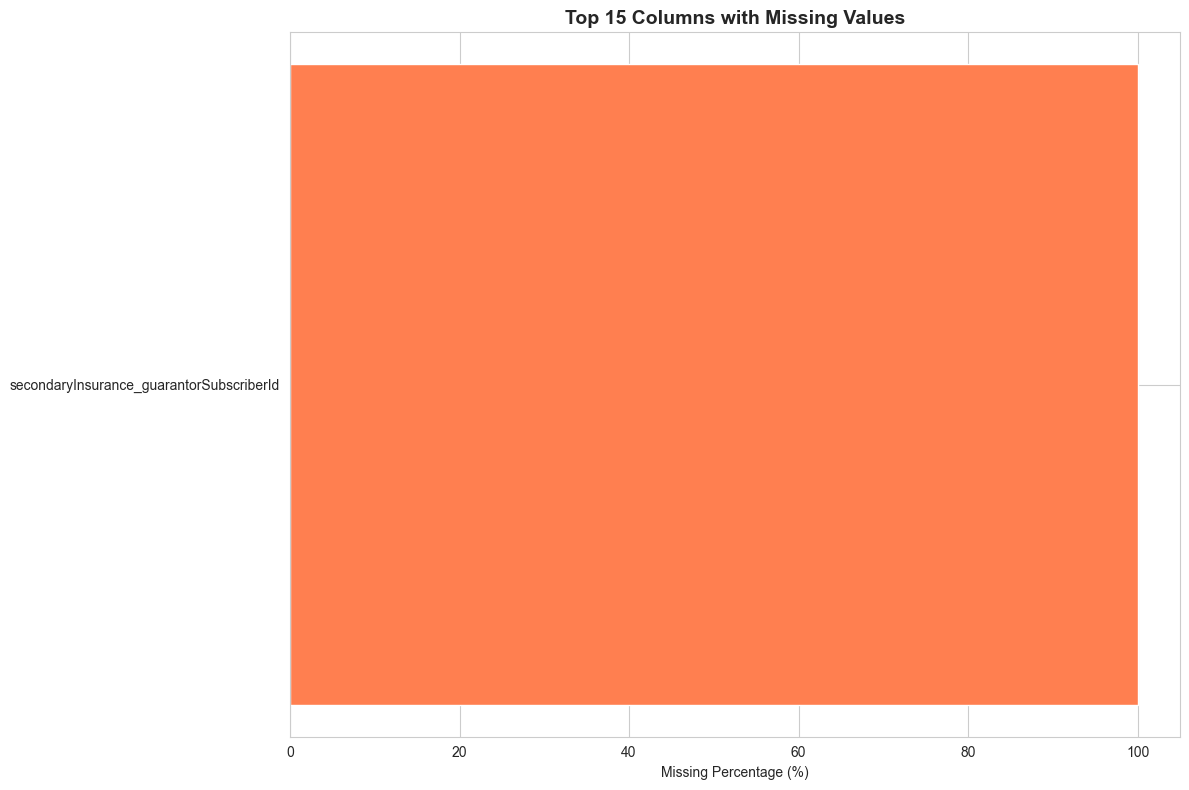

In [27]:
if len(missing_data) > 0:
    plt.figure(figsize=(12, 8))
    top_missing = missing_data.head(15)
    plt.barh(top_missing['Column'], top_missing['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Duplicate Records Check

In [28]:
duplicate_count = df.duplicated().sum()

print('='*70)
print('DUPLICATE RECORDS ANALYSIS')
print('='*70)
print(f'\nTotal duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    print(f'\nWarning: {duplicate_count} duplicate records found!')
else:
    print('\n✓ No duplicate records found. Data quality is good.')

DUPLICATE RECORDS ANALYSIS

Total duplicate rows: 0

✓ No duplicate records found. Data quality is good.


## 6. Statistical Summary

In [29]:
print('='*70)
print('STATISTICAL SUMMARY - NUMERICAL COLUMNS')
print('='*70)
df.describe()

STATISTICAL SUMMARY - NUMERICAL COLUMNS


,duration,phoneNo,smsTo,paidAmount,secondaryInsurance_guarantorSubscriberId
count,1000.000000,1.000000e+03,1.000000e+03,1000.0,0.0
mean,17.640000,6.056899e+09,6.056899e+09,0.0,NaN
std,5.715161,2.110571e+09,2.110571e+09,0.0,NaN
min,15.000000,2.130157e+09,2.130157e+09,0.0,NaN
25%,15.000000,4.421883e+09,4.421883e+09,0.0,NaN
50%,15.000000,6.260733e+09,6.260733e+09,0.0,NaN
75%,15.000000,7.600880e+09,7.600880e+09,0.0,NaN
max,30.000000,9.519938e+09,9.519938e+09,0.0,NaN


In [30]:
print('\nKey Metrics:')
print('-'*70)
if 'duration' in df.columns:
    print(f'Duration - Mean: {df["duration"].mean():.1f} min, Median: {df["duration"].median():.1f} min')
if 'paidAmount' in df.columns:
    print(f'Paid Amount - Mean: ${df["paidAmount"].mean():.2f}, Max: ${df["paidAmount"].max():.2f}')


Key Metrics:
----------------------------------------------------------------------
Duration - Mean: 17.6 min, Median: 15.0 min
Paid Amount - Mean: $0.00, Max: $0.00
